In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/emilyzohar/Desktop/Cafe TO Locations - 4326.csv')

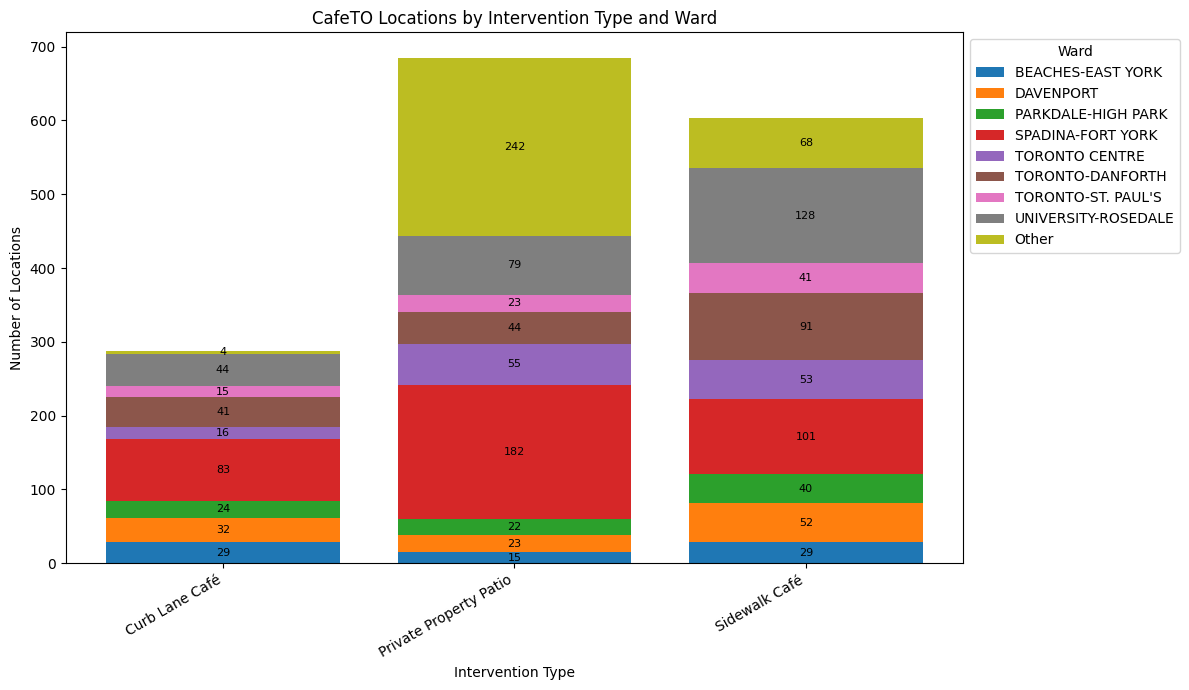

In [4]:
top_wards = df["WARD_NAME"].value_counts().head(8).index
df["WARD_GROUPED"] = df["WARD_NAME"]

for i in range(len(df)):
    if df.loc[i, "WARD_NAME"] not in top_wards:
        df.loc[i, "WARD_GROUPED"] = "Other"

counts = df.groupby(["INTERVENTION_TYPE", "WARD_GROUPED"]).size()
counts = counts.unstack(fill_value=0)

cols = list(counts.columns)
if "Other" in cols:
    cols.remove("Other")
    cols.append("Other")
counts = counts[cols]

fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(counts.index))
bottoms = [0] * len(counts.index)

for ward in counts.columns:
    values = list(counts[ward])
    ax.bar(x, values, bottom=bottoms, label=ward)
    
    for i in range(len(values)):
        if values[i] > 0:
            ax.text(
                i,
                bottoms[i] + values[i] / 2,
                str(values[i]),
                ha="center",
                va="center",
                fontsize=8
            )
    
    for i in range(len(bottoms)):
        bottoms[i] = bottoms[i] + values[i]

ax.set_title("CafeTO Locations by Intervention Type and Ward")
ax.set_xlabel("Intervention Type")
ax.set_ylabel("Number of Locations")

ax.set_xticks(list(x))
ax.set_xticklabels(counts.index, rotation=30, ha="right")

ax.legend(title="Ward", bbox_to_anchor=(1, 1), loc="upper left")

fig.tight_layout()
plt.show()

> What software did you use to create your data visualization?
 Python

> Who is your intended audience? 
City officials interested in the distribution per ward.

> What information or message are you trying to convey with your visualization? 
How many CafeTO locations there are per ward per type of property.

> What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
I wanted to convey the distribution of cafes across two different dimensions while still maintating detail about both, which lead me to create a stacked bar chart. I wanted the data to be clear so I added the raw numbers to the graph so readers were able to discern the actual proportions.

> How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
My visualization is reproducible because it uses publically available data and uses free software with basic packages. Ensuring that anyone interested in this question or looking into the data can create the same visualization.

> How did you ensure that your data visualization is accessible?  
I added values to the graph so it is able to cleary be legible. I used distinct colours so the different wards are clear. I labelled the data with medium-large font so it is clear.

> Who are the individuals and communities who might be impacted by your visualization?  
Residents of communities represented here and who are missing - policy makers will see this visualization and see if services are not being evenly dispresed. It will also affect those who own these or other Cafe's due to resource allocation. 

> How did you choose which features of your chosen dataset to include or exclude from your visualization? 
I decided to only highlight the larger wards as otherwise that legibility of the data would be impaired. I chose the two variables of interest as they were the most widely applicable rather than picking a low level data point such as reference number.

> What ‘underwater labour’ contributed to your final data visualization product?
I had to teach myself how to do stacked bar charts. The data itself required underwater labour to compile all the data, it is not specified how the data is collected but it is related to CafeTO and requires one to be aware of all sidewalk cafés, curb lane cafés and patios on private property.

https://open.toronto.ca/dataset/cafeto-curb-lane-parklet-cafe-locations/